# BaySeq

## Load and pre-process data

In [1]:
library(dplyr)
library(ggplot2)
library(tidyr)

# Load custom functions into pseudo-namespaces
bs <- new.env()
sys.source("scripts/BaySeq.R", envir = bs)
fn <- new.env()
sys.source("scripts/functions.R", envir = fn)

set.seed(123)

# Select data set
dataname <- "trauma"
dataname <- "Nurses"

#dataname <- "trauma_shuffled"
#dataname <- "Nurses_shuffled"

# Name of the column designating the center id
center_name <- "hospital"

# Only implemented for linear regression for now
use_local_intercepts <- TRUE

if (startsWith(dataname, "trauma")) {
        data(trauma, package = "BFI")
        data_raw <- trauma
} else if (startsWith(dataname, "Nurses")) {
        data(Nurses, package = "BFI")
        data_raw <- Nurses
} else {
        data_raw <- read.csv(paste0("data/raw/", dataname, ".csv"), row.names = 1)
}

# Shuffling center simulates homogeneous case
if (endsWith(dataname, "_shuffled")) {
        data_raw[[center_name]] <- sample(data_raw[[center_name]])
}

raw_dataname <- dataname
if (use_local_intercepts) {
    dataname <- paste0(dataname, "_", "local_int")
}

data_raw[[center_name]] <- factor(data_raw[[center_name]],
                        levels = sort(unique(data_raw[[center_name]]),
                        decreasing = FALSE))
dataname
head(data_raw)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Loading required package: metadat

Loading required package: numDeriv


Loading the 'metafor' package (version 4.8-0). For an
introduction to the package please type: help(metafor)




[1] "Nurses_local_int"

hospital,nurse,age,gender,experien,stress,wardtype,hospsize
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,36,0,11,7,0,2
1,2,45,0,20,7,0,2
1,3,32,0,7,7,0,2
1,4,57,1,25,6,0,2
1,5,46,1,22,6,0,2
1,6,60,1,22,6,0,2


In [2]:
table(data_raw[[center_name]])
median(table(data_raw[[center_name]]))
sort(unique(data_raw[[center_name]]), decreasing = FALSE)


 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 
36 36 37 38 36 36 40 40 40 40 43 51 52 50 46 40 36 39 40 40 40 36 36 36 36 

[1] 40

[1] 1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
25 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 25

In [3]:
scale_numeric_cols <- function(data) {
  data[] <- lapply(data, function(x) if (is.numeric(x)) scale(x)[, 1] else x)
  data
}

if (startsWith(dataname, "trauma")) {
    data_norm <- data_raw %>%
        # don't need to normalize within group as combined mean and sd can be computed without combining data
        mutate(
            age = scale(age),
            ISS = scale(ISS),
            GCS = scale(GCS)
        )

    model <- mortality ~ sex + age + ISS + GCS
    family <- "binomial" #(link = "logit")

} else if (startsWith(dataname, "Nurses")) {
    data_norm <- data_raw %>%
    mutate(
            age = scale(age),
            experience = scale(experien),
            stress = scale(stress),

            # keep numeric for now; fine if binary 0, 1
            #gender = factor(gender),
            #wardtype = factor(wardtype)
    )
    if (use_local_intercepts) {
        model_no_int <- as.formula(paste("stress ~ 0 + gender + age + experience +", center_name))
        model <- stress ~ gender + age + experience
    } else {
        model <- stress ~ gender + age + experience + wardtype
    }
    family <- "gaussian"

} else {
  stop()
}

covariates <- attr(terms(model), "term.labels")
covariates_local <- covariates[covariates != center_name]
target <- all.vars(model)[1]

if (center_name %in% covariates) {
    data <- data_norm[c(target, covariates)]
} else {
    data <- data_norm[c(center_name, target, covariates)]
}

data_split <- data %>%
  group_by(.data[[center_name]]) %>%
  group_split()

n_centers <- length(data_split)
head(data_split[[1]])

hospital,stress,gender,age,experience
<fct>,"<dbl[,1]>",<dbl>,"<dbl[,1]>","<dbl[,1]>"
1,2.065329,0,-0.5817336,-1.0024484
1,2.065329,0,0.1656757,0.4870737
1,2.065329,0,-0.9139156,-1.6644582
1,1.044405,1,1.1622216,1.3145860
1,1.044405,1,0.2487212,0.8180786
1,1.044405,1,1.4113581,0.8180786


# Using Bayesian Sequential Updating

In [4]:
bstats <- bs$bayseq_prepare(target, covariates, model, data_split, n_centers, use_local_intercepts, center_name)
params_seq <- bs$bayseq_oneshot(bstats, n_centers, use_local_intercepts, family,
                                covariates, epsilon = 1e-10, center_name)

df_seq <- bs$tidy_results(params_seq, use_local_intercepts)
df_seq["Covariate"][df_seq["Covariate"] == "Intercept"] <- "(Intercept)"
df_seq

[1] "Bayesian linear regression"
[1] "gender"     "age"        "experience"


Method,Covariate,Estimate,lower,upper
<chr>,<chr>,<dbl>,<dbl>,<dbl>
BaySeq,gender,-0.4737137,-0.5852068,-0.3622206
BaySeq,age,0.2470454,0.1619393,0.3321516
BaySeq,experience,-0.3570065,-0.4422715,-0.2717415
BaySeq,sigma2,0.6128582,0.5636223,0.6716752


# Using Multivariate Meta-Analysis

In [5]:
# Fit local GLMs
res_local <- fn$fit_local_glms(data_split, model, target, covariates, center_name)
coef_list <- res_local$coef_list
se_list <- res_local$se_list
cov_list <- res_local$cov_list

In [6]:
# Meta-analyse GLM parameters
df_meta_mv_fe <- fn$fit_mv_meta_fixed(coef_list, cov_list)
df_meta_mv_reml <- fn$fit_mv_meta_random(coef_list, cov_list, method="REML")

# add simple mean of error variances
if (family == "gaussian") {
    sigma2 <- mean(res_local$sigma2_list)

    use_boot_CI <- FALSE
    if (use_boot_CI) {
        boot_means <- replicate(10000, mean(sample(res_local$sigma2_list, replace = TRUE)))
        ci <- quantile(boot_means, c(0.025, 0.975))
        lower <- ci[[1]]
        upper <- ci[[2]]
    } else {
        sigma2_sd <- sd(res_local$sigma2_list)
        n <- length(res_local$sigma2_list)
        error_margin <- qt(0.975, df = n - 1) * sigma2_sd / sqrt(n)
        lower <- sigma2 - error_margin
        upper <- sigma2 + error_margin
    }

    row <- list("sigma2", sigma2, lower, upper, "FE")
    df_sigma2 <- as.data.frame(row, stringsAsFactors = FALSE)
    colnames(df_sigma2) <- colnames(df_meta_mv_fe)
    df_meta_mv_fe <- rbind(df_meta_mv_fe, df_sigma2)

    row <- list("sigma2", sigma2, lower, upper, "REML")
    df_sigma2 <- as.data.frame(row, stringsAsFactors = FALSE)
    colnames(df_sigma2) <- colnames(df_meta_mv_fe)
    df_meta_mv_reml <- rbind(df_meta_mv_reml, df_sigma2)
}
df_meta_mv_fe
df_meta_mv_reml

Covariate,Estimate,lower,upper,Method
<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),0.4761705,0.3941512,0.5581899,FE
gender,-0.4824995,-0.5783017,-0.3866972,FE
age,0.2643039,0.1915361,0.3370718,FE
experience,-0.3821681,-0.4554922,-0.3088439,FE
sigma2,0.6352886,0.4877670,0.7828101,FE


Covariate,Estimate,lower,upper,Method
<chr>,<dbl>,<dbl>,<dbl>,<chr>
(Intercept),0.4528117,0.3550594,0.5505641,REML
gender,-0.4983339,-0.6082770,-0.3883908,REML
age,0.2266000,0.1362747,0.3169252,REML
experience,-0.3869053,-0.4780777,-0.2957329,REML
sigma2,0.6352886,0.4877670,0.7828101,REML


# Using BFI

In [7]:
res_bfi_sub <- fn$bfi_sub(data_split, family, target, covariates, center_name)
df_bfi <- fn$fit_bfi(data_split, family, res_bfi_sub, use_local_intercepts)


Summary of the BFI model:

    Family: ‘gaussian’ 
      Link: ‘identity’

Coefficients:

                  Estimate Std.Dev CI 2.5% CI 97.5%
(Intercept)_loc1    0.6633  0.1590  0.3517   0.9748
(Intercept)_loc2    0.1958  0.0924  0.0147   0.3769
(Intercept)_loc3    0.2771  0.1652 -0.0466   0.6008
(Intercept)_loc4    0.6851  0.1065  0.4763   0.8939
(Intercept)_loc5    0.8734  0.0991  0.6791   1.0676
(Intercept)_loc6   -0.1097  0.1375 -0.3793   0.1598
(Intercept)_loc7    0.1014  0.0764 -0.0483   0.2511
(Intercept)_loc8    0.6104  0.0836  0.4465   0.7742
(Intercept)_loc9   -1.0940  0.1751 -1.4371  -0.7509
(Intercept)_loc10   0.8805  0.0934  0.6974   1.0637
(Intercept)_loc11   0.0587  0.1121 -0.1610   0.2784
(Intercept)_loc12   0.3139  0.1191  0.0805   0.5473
(Intercept)_loc13  -0.2119  0.1306 -0.4679   0.0441
(Intercept)_loc14  -0.2066  0.1082 -0.4186   0.0055
(Intercept)_loc15   0.6379  0.1364  0.3705   0.9053
(Intercept)_loc16   0.4868  0.1335  0.2252   0.7484
(Intercept)_loc17   0.259

# Using combined data (ground truth)

In [8]:
df_combined <- fn$fit_combined_glm(model, model_no_int, use_local_intercepts, center_name)

Waiting for profiling to be done...



# Compare methods

In [9]:
library(ggplot2)
library(ggpubr)
library(stringr)

method_order <- c("Combined", "BaySeq", "BFI", "FE", "REML")
df_merged <- rbind(df_combined, df_seq, df_bfi, df_meta_mv_fe, df_meta_mv_reml)  # must match above

if (use_local_intercepts) {
  df_merged <- df_merged %>%
    filter(
      Covariate != "(Intercept)",
      !str_starts(Covariate, "Intercept_")
    )
}

df_merged$Method <- factor(df_merged$Method, levels = method_order)
write.csv(df_merged, paste0("data/summarized/params.", dataname, ".csv"))

huemap <- setNames(get_palette(palette = "npg", length(levels(df_merged$Method))), levels(df_merged$Method))

Saving 7 x 7 in image


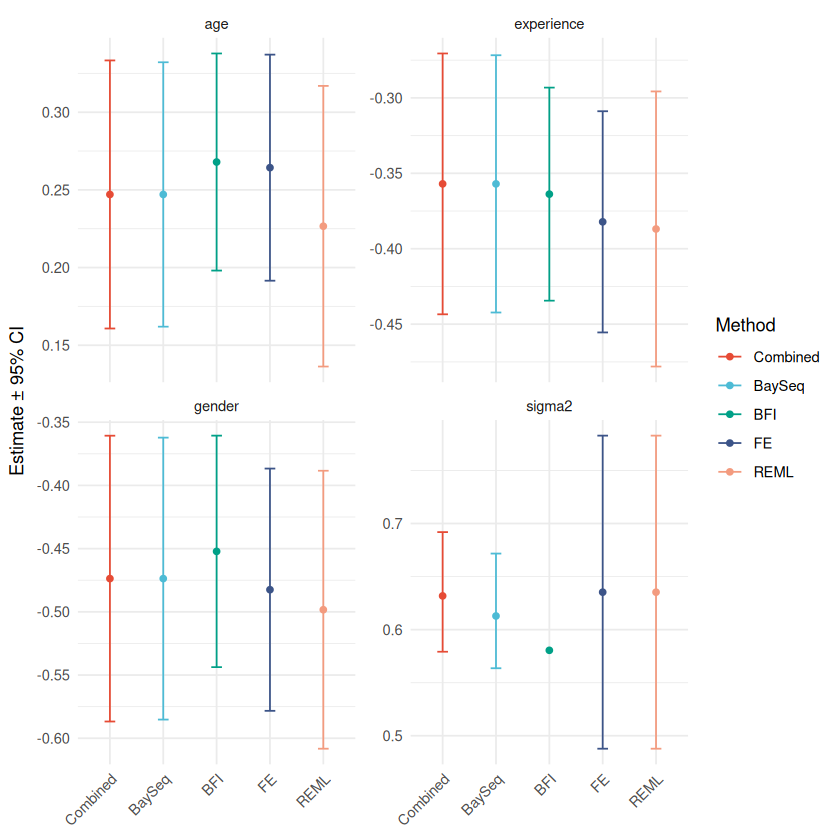

In [10]:
plot_params <- function(dataname, df_merged) {
  p <- ggplot(df_merged, aes(x = Method, y = Estimate, color = Method)) +
  geom_point(position = position_dodge(width = 0.5)) +
  geom_errorbar(aes(ymin = lower, ymax = upper), 
                width = 0.2,
                position = position_dodge(width = 0.5)) +
  scale_color_manual(values = huemap) +
  facet_wrap(~ Covariate, scales = "free_y") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(y = "Estimate ± 95% CI", x = NULL)

  ggsave(paste0("figures_tmp/params.", dataname, ".png"), bg = "white")
  p
}

plot_params(dataname, df_merged)

if (startsWith(dataname, "sim-")) {
    simtruth <- read.csv(paste0("data/raw/", raw_dataname, ".truth.csv"))
    simtruth
}

 # SessionInfo

In [11]:
sink("session_info.txt")
print(sessionInfo())
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 24.04.2 LTS

Matrix products: default
BLAS/LAPACK: /home/pedege/miniforge3/envs/pydata/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Zurich
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] stringr_1.5.1       ggpubr_0.6.1        BFI_3.1.0          
 [4] metafor_4.8-0       numDeriv_2016.8-1.1 metadat_1.4-0      
 [7] Matrix_1.6-5        invgamma_1.2        tidyr_1.3.1        
[10] ggplot2_3.5.2       dply

# To do

- why does bayseq yield very different sigma2 to combined when using local intercepts?
- CI of error variance?
- use marginal distributions for posterior CI?